In [7]:
pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


# E-commerce Return Analysis and Prediction

This notebook solves an interview task using an e-commerce orders dataset.

The work is divided into three parts:

1. Data Wrangling
2. Exploratory Data Analysis
3. Simple Machine Learning Modeling

## Part 1: Load and Inspect the Dataset

Before cleaning, analyzing, or modeling the data, I first inspect the dataset structure.

This includes:

- dataset shape
- column names
- data types
- missing values
- sample rows

In [8]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Get project root folder
PROJECT_ROOT = Path.cwd()

# If notebook runs from notebooks folder, move one level up
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "ecommerce_orders.csv"

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project root: d:\11.Running Projects\interview-return-analysis
Dataset path: d:\11.Running Projects\interview-return-analysis\data\raw\ecommerce_orders.csv
Dataset exists: True


In [10]:
df = pd.read_csv(DATA_PATH)

df.head()

,order_id,customer_id,order_date,product_category,amount,discount_pct,is_returned
0,ORD_00180,CUST_012,7/1/2023,Books,15.15,25.0,0
1,ORD_00303,CUST_007,7/2/2023,Clothing,117.31,10.0,1
2,ORD_00421,CUST_054,7/2/2023,Electronics,643.68,25.0,0
3,ORD_00163,CUST_005,7/2/2023,Clothing,134.04,10.0,0
4,ORD_00032,CUST_075,7/4/2023,Food,17.79,50.0,0


In [11]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape:
(500, 7)

Column names:
['order_id', 'customer_id', 'order_date', 'product_category', 'amount', 'discount_pct', 'is_returned']

Data types:
order_id                str
customer_id             str
order_date              str
product_category        str
amount              float64
discount_pct        float64
is_returned           int64
dtype: object

Missing values:
order_id             0
customer_id          0
order_date           0
product_category     0
amount              10
discount_pct         8
is_returned          0
dtype: int64


In [12]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary

,missing_count,missing_percentage
order_id,0,0.0
customer_id,0,0.0
order_date,0,0.0
product_category,0,0.0
amount,10,2.0
discount_pct,8,1.6
is_returned,0,0.0


## Part 1: Data Wrangling

In this step, I convert the order date column into a proper datetime format, create the `net_amount` column, and filter the dataset to include only orders from the last 6 months of the dataset.

I use the maximum order date in the dataset as the reference date instead of today's date because the dataset may not contain current real-time orders.

In [13]:
# Convert order_date to datetime format
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

# Check date conversion
print("Data type of order_date:", df["order_date"].dtype)
print("Invalid dates after conversion:", df["order_date"].isnull().sum())

print("Minimum order date:", df["order_date"].min())
print("Maximum order date:", df["order_date"].max())

Data type of order_date: datetime64[us]
Invalid dates after conversion: 0
Minimum order date: 2023-07-01 00:00:00
Maximum order date: 2024-06-30 00:00:00


In [14]:
# Create net_amount column
df["net_amount"] = df["amount"] * (1 - df["discount_pct"] / 100)

# Display sample rows to verify the calculation
df[["order_id", "amount", "discount_pct", "net_amount"]].head(10)

,order_id,amount,discount_pct,net_amount
0,ORD_00180,15.15,25.0,11.3625
1,ORD_00303,117.31,10.0,105.5790
2,ORD_00421,643.68,25.0,482.7600
3,ORD_00163,134.04,10.0,120.6360
4,ORD_00032,17.79,50.0,8.8950
5,ORD_00231,646.11,0.0,646.1100
6,ORD_00391,198.29,15.0,168.5465
7,ORD_00367,770.89,0.0,770.8900
8,ORD_00432,157.07,20.0,125.6560
9,ORD_00150,70.16,10.0,63.1440


In [15]:
# Find the latest order date in the dataset
max_order_date = df["order_date"].max()

# Calculate cutoff date: 6 months before the latest order date
cutoff_date = max_order_date - pd.DateOffset(months=6)

# Filter orders placed in the last 6 months of the dataset
df_last_6_months = df[df["order_date"] >= cutoff_date].copy()

print("Maximum order date in dataset:", max_order_date)
print("Cutoff date for last 6 months:", cutoff_date)
print("Shape before filtering:", df.shape)
print("Shape after filtering:", df_last_6_months.shape)

print("Filtered minimum date:", df_last_6_months["order_date"].min())
print("Filtered maximum date:", df_last_6_months["order_date"].max())

Maximum order date in dataset: 2024-06-30 00:00:00
Cutoff date for last 6 months: 2023-12-30 00:00:00
Shape before filtering: (500, 8)
Shape after filtering: (233, 8)
Filtered minimum date: 2023-12-31 00:00:00
Filtered maximum date: 2024-06-30 00:00:00


In [16]:
# Find the latest order date in the dataset
max_order_date = df["order_date"].max()

# Calculate cutoff date: 6 months before the latest order date
cutoff_date = max_order_date - pd.DateOffset(months=6)

# Filter orders placed in the last 6 months of the dataset
df_last_6_months = df[df["order_date"] >= cutoff_date].copy()

print("Maximum order date in dataset:", max_order_date)
print("Cutoff date for last 6 months:", cutoff_date)
print("Shape before filtering:", df.shape)
print("Shape after filtering:", df_last_6_months.shape)

print("Filtered minimum date:", df_last_6_months["order_date"].min())
print("Filtered maximum date:", df_last_6_months["order_date"].max())

Maximum order date in dataset: 2024-06-30 00:00:00
Cutoff date for last 6 months: 2023-12-30 00:00:00
Shape before filtering: (500, 8)
Shape after filtering: (233, 8)
Filtered minimum date: 2023-12-31 00:00:00
Filtered maximum date: 2024-06-30 00:00:00


In [17]:
# Save the filtered dataset for later analysis
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "orders_last_6_months.csv"

df_last_6_months.to_csv(PROCESSED_PATH, index=False)

print("Processed dataset saved to:", PROCESSED_PATH)
print("File exists:", PROCESSED_PATH.exists())

Processed dataset saved to: d:\11.Running Projects\interview-return-analysis\data\processed\orders_last_6_months.csv
File exists: True


In [18]:
df_last_6_months.head()

,order_id,customer_id,order_date,product_category,amount,discount_pct,is_returned,net_amount
267,ORD_00045,CUST_057,2023-12-31,Food,24.41,NaN,0,NaN
268,ORD_00449,CUST_068,2023-12-31,Books,27.57,25.0,0,20.6775
269,ORD_00186,CUST_032,2024-01-02,Food,54.50,10.0,0,49.0500
270,ORD_00128,CUST_061,2024-01-02,Clothing,174.93,15.0,0,148.6905
271,ORD_00059,CUST_074,2024-01-02,Electronics,83.92,20.0,0,67.1360


In [19]:
df_last_6_months.isnull().sum()

order_id            0
customer_id         0
order_date          0
product_category    0
amount              5
discount_pct        2
is_returned         0
net_amount          7
dtype: int64

## Part 2: Exploratory Data Analysis

In this section, I analyze return behavior and customer spending patterns.

The main questions are:

1. Which product category has the highest return rate?
2. Is there a correlation between discount percentage and returned orders?
3. Who are the top 5 customers by total net amount spent?

In [20]:
# Calculate return rate by product category
category_return_rate = (
    df_last_6_months
    .groupby("product_category")["is_returned"]
    .agg(
        total_orders="count",
        returned_orders="sum",
        return_rate="mean"
    )
    .sort_values("return_rate", ascending=False)
)

category_return_rate

,total_orders,returned_orders,return_rate
product_category,,,
Food,37,9,0.243243
Clothing,72,16,0.222222
Electronics,74,13,0.175676
Books,50,5,0.100000


In [21]:
highest_return_category = category_return_rate.index[0]
highest_return_rate = category_return_rate.iloc[0]["return_rate"]

print("Product category with the highest return rate:", highest_return_category)
print("Highest return rate:", round(highest_return_rate * 100, 2), "%")

Product category with the highest return rate: Food
Highest return rate: 24.32 %


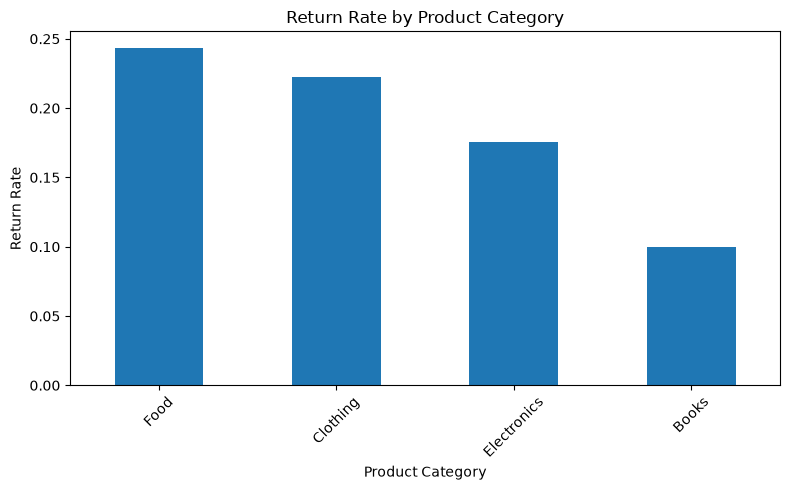

Plot saved to: d:\11.Running Projects\interview-return-analysis\outputs\plots\category_return_rate.png


In [22]:
# Plot return rate by product category
plt.figure(figsize=(8, 5))

category_return_rate["return_rate"].plot(kind="bar")

plt.title("Return Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Return Rate")
plt.xticks(rotation=45)
plt.tight_layout()

CATEGORY_PLOT_PATH = PROJECT_ROOT / "outputs" / "plots" / "category_return_rate.png"
plt.savefig(CATEGORY_PLOT_PATH, bbox_inches="tight")

plt.show()

print("Plot saved to:", CATEGORY_PLOT_PATH)

In [23]:
# Calculate correlation between discount percentage and return status
discount_return_corr = df_last_6_months["discount_pct"].corr(df_last_6_months["is_returned"])

print("Correlation between discount_pct and is_returned:", round(discount_return_corr, 4))

Correlation between discount_pct and is_returned: 0.1254


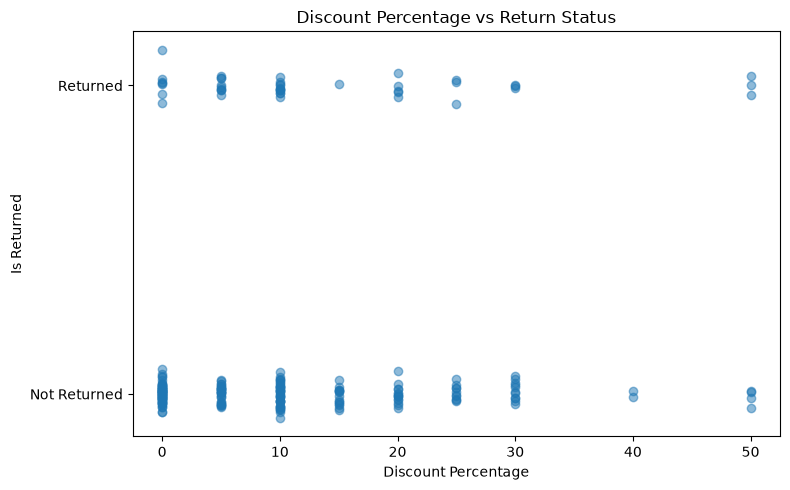

Plot saved to: d:\11.Running Projects\interview-return-analysis\outputs\plots\discount_vs_return.png


In [24]:
# Create scatter plot for discount percentage vs return status

np.random.seed(42)

plt.figure(figsize=(8, 5))

y_jitter = df_last_6_months["is_returned"] + np.random.normal(
    0, 
    0.03, 
    size=len(df_last_6_months)
)

plt.scatter(
    df_last_6_months["discount_pct"],
    y_jitter,
    alpha=0.5
)

plt.title("Discount Percentage vs Return Status")
plt.xlabel("Discount Percentage")
plt.ylabel("Is Returned")
plt.yticks([0, 1], ["Not Returned", "Returned"])
plt.tight_layout()

DISCOUNT_PLOT_PATH = PROJECT_ROOT / "outputs" / "plots" / "discount_vs_return.png"
plt.savefig(DISCOUNT_PLOT_PATH, bbox_inches="tight")

plt.show()

print("Plot saved to:", DISCOUNT_PLOT_PATH)

In [25]:
# Find top 5 customers by total net amount spent
top_5_customers = (
    df_last_6_months
    .groupby("customer_id")["net_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_5_customers

customer_id
CUST_054    1423.1985
CUST_001    1328.2700
CUST_055    1273.4785
CUST_059    1199.0040
CUST_047    1132.3395
Name: net_amount, dtype: float64

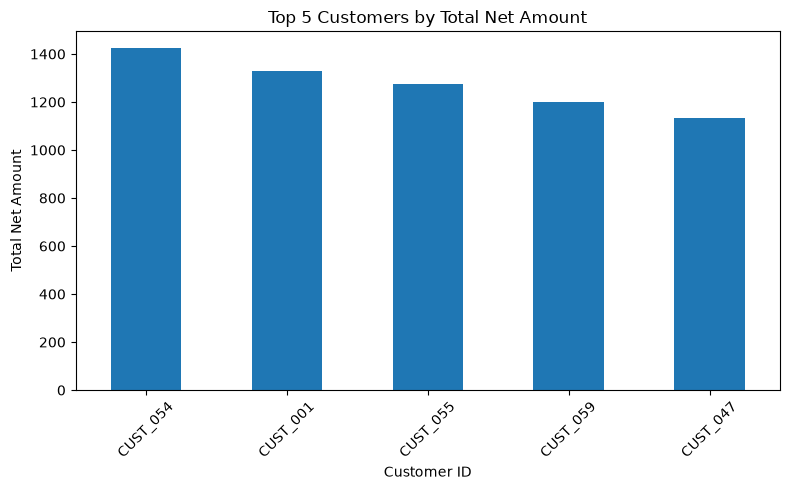

Plot saved to: d:\11.Running Projects\interview-return-analysis\outputs\plots\top_5_customers.png


In [26]:
plt.figure(figsize=(8, 5))

top_5_customers.plot(kind="bar")

plt.title("Top 5 Customers by Total Net Amount")
plt.xlabel("Customer ID")
plt.ylabel("Total Net Amount")
plt.xticks(rotation=45)
plt.tight_layout()

CUSTOMER_PLOT_PATH = PROJECT_ROOT / "outputs" / "plots" / "top_5_customers.png"
plt.savefig(CUSTOMER_PLOT_PATH, bbox_inches="tight")

plt.show()

print("Plot saved to:", CUSTOMER_PLOT_PATH)

## Part 3: Modeling

In this section, I build a simple machine learning model to predict whether an order will be returned.

Since the target column `is_returned` has two values, 0 and 1, this is a binary classification problem.

I use Logistic Regression as a simple baseline model because it is easy to interpret and suitable for binary classification.

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

In [28]:
# Check target distribution
target_counts = df_last_6_months["is_returned"].value_counts()
target_percentage = df_last_6_months["is_returned"].value_counts(normalize=True) * 100

print("Target counts:")
print(target_counts)

print("\nTarget percentage:")
print(target_percentage)

Target counts:
is_returned
0    190
1     43
Name: count, dtype: int64

Target percentage:
is_returned
0    81.545064
1    18.454936
Name: proportion, dtype: float64


In [29]:
# Create a modeling copy
model_df = df_last_6_months.copy()

# Create order_month as a simple date-based feature
model_df["order_month"] = model_df["order_date"].dt.month

# Select features and target
features = [
    "amount",
    "discount_pct",
    "net_amount",
    "product_category",
    "order_month"
]

target = "is_returned"

X = model_df[features]
y = model_df[target]

print("Feature columns:")
print(X.columns.tolist())

print("\nTarget column:")
print(target)

Feature columns:
['amount', 'discount_pct', 'net_amount', 'product_category', 'order_month']

Target column:
is_returned


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (186, 5)
Testing set shape: (47, 5)


In [31]:
numeric_features = ["amount", "discount_pct", "net_amount", "order_month"]
categorical_features = ["product_category"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

In [32]:
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [33]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [34]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("Accuracy:", round(accuracy, 4))
print("F1 Score:", round(f1, 4))
print("AUC:", round(auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5319
F1 Score: 0.2143
AUC: 0.4942

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.58      0.67        38
           1       0.16      0.33      0.21         9

    accuracy                           0.53        47
   macro avg       0.47      0.46      0.44        47
weighted avg       0.67      0.53      0.58        47


Confusion Matrix:
[[22 16]
 [ 6  3]]


### Modeling Summary

I used Logistic Regression because the target variable `is_returned` is binary.

The selected features were:

- amount
- discount_pct
- net_amount
- product_category
- order_month

I used F1 Score as the main metric because returned orders may be fewer than non-returned orders, so accuracy alone can be misleading.

The model provides a simple baseline for predicting returned orders.